# Filtragem high-boost

Realce de detalhes via *unsharp masking* e sua generalização, o **high-boost**:

1. Borrar a imagem: $\bar f = f * h_{\text{passa-baixa}}$
2. Máscara (detalhes): $g_{\text{mask}} = f - \bar f$
3. Somar de volta com peso $k$: $g = f + k \cdot g_{\text{mask}}$

- $k = 1$ → *unsharp masking*
- $k > 1$ → *high-boost*
- $0 \le k < 1$ → realce atenuado

Forma equivalente: $g = (1 + k) f - k \bar f$ — é exatamente o que `cv2.addWeighted` calcula, então usamos ele como referência para validar a implementação manual.

(512, 512) uint8


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

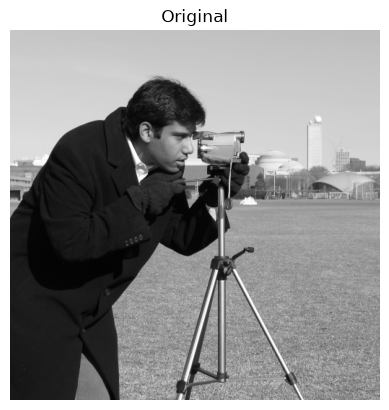

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import data

img = data.camera()  # tons de cinza, uint8, bordas bem definidas
print(img.shape, img.dtype)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

## Passa-baixa do zero

Filtro da média (box) $n \times n$ implementado com padding por reflexão. `np.pad(mode="reflect")` equivale ao `cv2.BORDER_REFLECT_101` (padrão do OpenCV), então o resultado deve bater com `cv2.blur`.

In [2]:
def box_blur_from_scratch(img, n):
    """Filtro da média n x n (n ímpar), retornando float64."""
    assert n % 2 == 1, "n deve ser ímpar"
    r = n // 2
    padded = np.pad(img.astype(np.float64), r, mode="reflect")
    h, w = img.shape
    acc = np.zeros((h, w), dtype=np.float64)
    # soma das n*n janelas deslocadas (vetorizado, sem loop por pixel)
    for dy in range(n):
        for dx in range(n):
            acc += padded[dy:dy + h, dx:dx + w]
    return acc / (n * n)

N = 9
blur_manual = box_blur_from_scratch(img, N)
blur_cv2 = cv2.blur(img.astype(np.float64), (N, N))

diff = np.abs(blur_manual - blur_cv2)
assert diff.max() < 1e-9, f"diferença máxima entre manual e cv2.blur: {diff.max()}"
print("OK: box blur manual bate com cv2.blur (diferença máxima:", diff.max(), ")")

OK: box blur manual bate com cv2.blur (diferença máxima: 2.842170943040401e-14 )


## Máscara de detalhes e high-boost

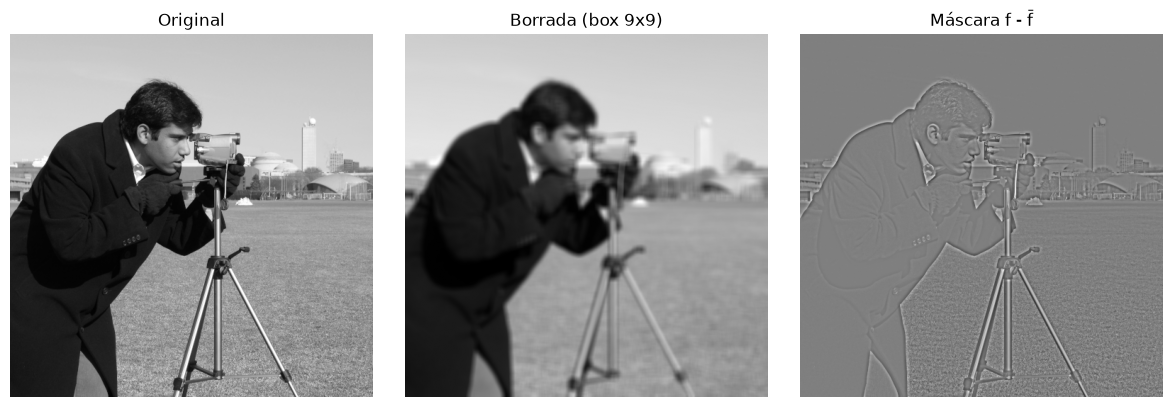

In [3]:
def high_boost_from_scratch(img, blurred, k):
    """g = f + k * (f - f_borrada), saturado em [0, 255]."""
    f = img.astype(np.float64)
    mask = f - blurred
    return np.clip(np.round(f + k * mask), 0, 255).astype(np.uint8)

mask = img.astype(np.float64) - blur_manual

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img, cmap="gray"); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(blur_manual, cmap="gray"); axes[1].set_title(f"Borrada (box {N}x{N})"); axes[1].axis("off")
# máscara tem valores negativos: centralizada em 0 para visualização
lim = np.abs(mask).max()
axes[2].imshow(mask, cmap="gray", vmin=-lim, vmax=lim); axes[2].set_title("Máscara f - f̄"); axes[2].axis("off")
plt.tight_layout()

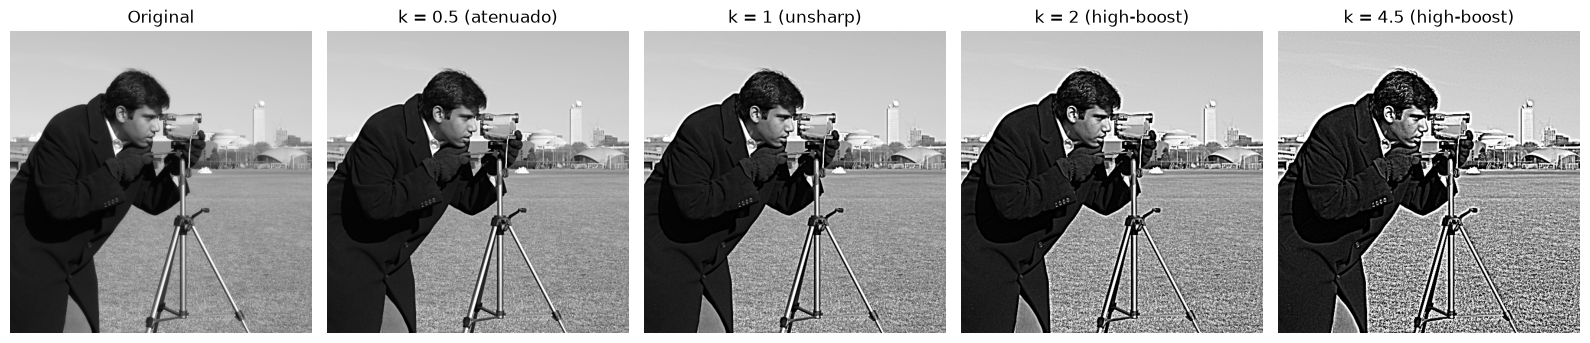

In [4]:
ks = [0.5, 1, 2, 4.5]
results = {k: high_boost_from_scratch(img, blur_manual, k) for k in ks}

fig, axes = plt.subplots(1, len(ks) + 1, figsize=(16, 4))
axes[0].imshow(img, cmap="gray"); axes[0].set_title("Original"); axes[0].axis("off")
for ax, k in zip(axes[1:], ks):
    label = "unsharp" if k == 1 else ("high-boost" if k > 1 else "atenuado")
    ax.imshow(results[k], cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"k = {k} ({label})")
    ax.axis("off")
plt.tight_layout()

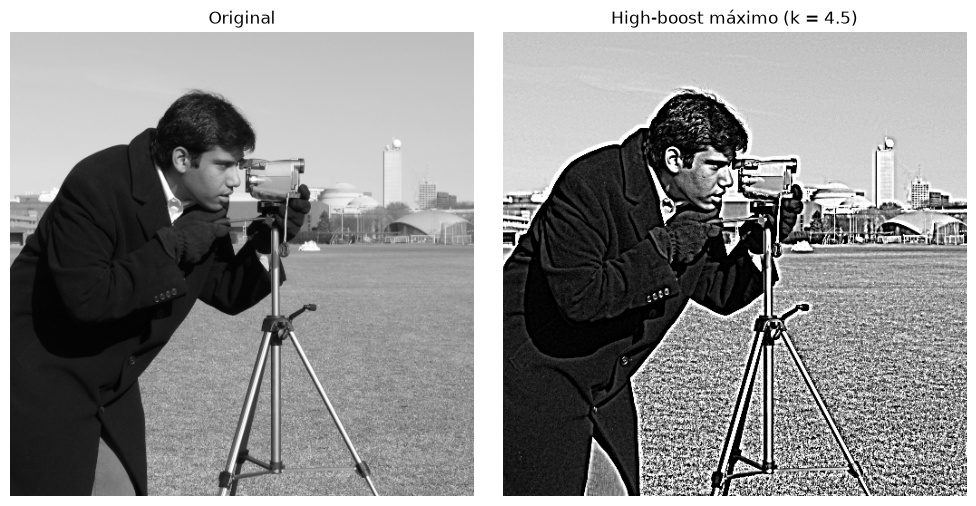

In [5]:
k_max = max(ks)  # maior k testado (4.5)
g_max = results[k_max]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img, cmap="gray", vmin=0, vmax=255); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(g_max, cmap="gray", vmin=0, vmax=255); axes[1].set_title(f"High-boost máximo (k = {k_max})"); axes[1].axis("off")
plt.tight_layout()


## Perfil de intensidade

Uma linha horizontal da imagem mostra o efeito nas bordas: o high-boost cria *overshoot* / *undershoot* (halos) nos degraus, e quanto maior $k$, mais forte — até saturar em 0 ou 255.

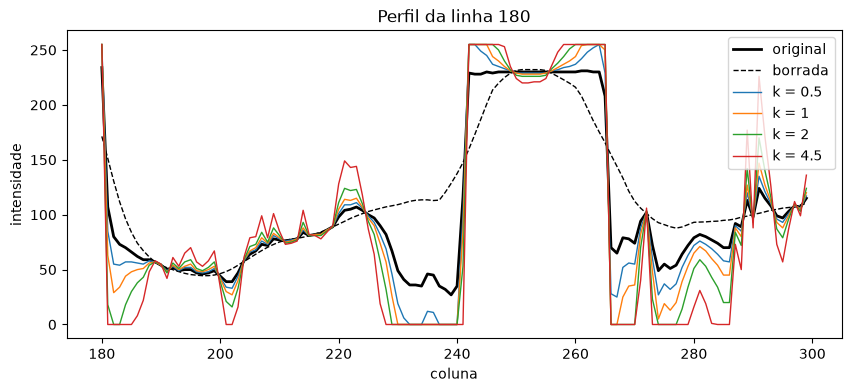

In [6]:
row, c0, c1 = 180, 180, 300  # trecho que cruza a câmera e o tripé
xs = np.arange(c0, c1)

plt.figure(figsize=(10, 4))
plt.plot(xs, img[row, c0:c1], "k", lw=2, label="original")
plt.plot(xs, blur_manual[row, c0:c1], "k--", lw=1, label="borrada")
for k in ks:
    plt.plot(xs, results[k][row, c0:c1], lw=1, label=f"k = {k}")
plt.xlabel("coluna")
plt.ylabel("intensidade")
plt.title(f"Perfil da linha {row}")
plt.legend()

In [7]:
# self-check: g = (1 + k) f - k f̄ é exatamente cv2.addWeighted(f, 1 + k, f̄, -k, 0)
blur_cv2_u8 = cv2.blur(img, (N, N))  # referência inteiramente via OpenCV
for k in ks:
    ref = cv2.addWeighted(img, 1 + k, blur_cv2_u8, -k, 0)
    d = np.abs(results[k].astype(int) - ref.astype(int))
    # cv2.blur em uint8 arredonda a média (erro <= 0.5), que o addWeighted amplifica por k
    tol = np.ceil(0.5 * k) + 1
    assert d.max() <= tol, f"k={k}: diferença máxima {d.max()} > {tol}"
    print(f"OK k={k}: high-boost manual bate com cv2.addWeighted (diferença máxima: {d.max()})")

OK k=0.5: high-boost manual bate com cv2.addWeighted (diferença máxima: 1)
OK k=1: high-boost manual bate com cv2.addWeighted (diferença máxima: 0)
OK k=2: high-boost manual bate com cv2.addWeighted (diferença máxima: 1)
OK k=4.5: high-boost manual bate com cv2.addWeighted (diferença máxima: 3)
